In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.utils import Sequence
from imgaug.augmentables.kps import KeypointsOnImage, Keypoint
import imgaug.augmenters as iaa
import os
import numpy as np
from tqdm import tqdm
from sklearn.model_selection import train_test_split
import keras
from keras import layers
import tensorflow as tf
from keras import backend as K
%matplotlib inline

In [2]:
df=pd.read_csv("/kaggle/input/facial-keypoints-detection/training.zip",compression="zip")

In [3]:
df.head()

,left_eye_center_x,left_eye_center_y,right_eye_center_x,right_eye_center_y,left_eye_inner_corner_x,left_eye_inner_corner_y,left_eye_outer_corner_x,left_eye_outer_corner_y,right_eye_inner_corner_x,right_eye_inner_corner_y,...,nose_tip_y,mouth_left_corner_x,mouth_left_corner_y,mouth_right_corner_x,mouth_right_corner_y,mouth_center_top_lip_x,mouth_center_top_lip_y,mouth_center_bottom_lip_x,mouth_center_bottom_lip_y,Image
0,66.033564,39.002274,30.227008,36.421678,59.582075,39.647423,73.130346,39.969997,36.356571,37.389402,...,57.066803,61.195308,79.970165,28.614496,77.388992,43.312602,72.935459,43.130707,84.485774,238 236 237 238 240 240 239 241 241 243 240 23...
1,64.332936,34.970077,29.949277,33.448715,58.856170,35.274349,70.722723,36.187166,36.034723,34.361532,...,55.660936,56.421447,76.352000,35.122383,76.047660,46.684596,70.266553,45.467915,85.480170,219 215 204 196 204 211 212 200 180 168 178 19...
2,65.057053,34.909642,30.903789,34.909642,59.412000,36.320968,70.984421,36.320968,37.678105,36.320968,...,53.538947,60.822947,73.014316,33.726316,72.732000,47.274947,70.191789,47.274947,78.659368,144 142 159 180 188 188 184 180 167 132 84 59 ...
3,65.225739,37.261774,32.023096,37.261774,60.003339,39.127179,72.314713,38.380967,37.618643,38.754115,...,54.166539,65.598887,72.703722,37.245496,74.195478,50.303165,70.091687,51.561183,78.268383,193 192 193 194 194 194 193 192 168 111 50 12 ...
4,66.725301,39.621261,32.244810,38.042032,58.565890,39.621261,72.515926,39.884466,36.982380,39.094852,...,64.889521,60.671411,77.523239,31.191755,76.997301,44.962748,73.707387,44.227141,86.871166,147 148 160 196 215 214 216 217 219 220 206 18...


In [4]:
df.shape

(7049, 31)

In [5]:
df.isnull().sum()

left_eye_center_x              10
left_eye_center_y              10
right_eye_center_x             13
right_eye_center_y             13
left_eye_inner_corner_x      4778
left_eye_inner_corner_y      4778
left_eye_outer_corner_x      4782
left_eye_outer_corner_y      4782
right_eye_inner_corner_x     4781
right_eye_inner_corner_y     4781
right_eye_outer_corner_x     4781
right_eye_outer_corner_y     4781
left_eyebrow_inner_end_x     4779
left_eyebrow_inner_end_y     4779
left_eyebrow_outer_end_x     4824
left_eyebrow_outer_end_y     4824
right_eyebrow_inner_end_x    4779
right_eyebrow_inner_end_y    4779
right_eyebrow_outer_end_x    4813
right_eyebrow_outer_end_y    4813
nose_tip_x                      0
nose_tip_y                      0
mouth_left_corner_x          4780
mouth_left_corner_y          4780
mouth_right_corner_x         4779
mouth_right_corner_y         4779
mouth_center_top_lip_x       4774
mouth_center_top_lip_y       4774
mouth_center_bottom_lip_x      33
mouth_center_b

In [6]:
cols=df.select_dtypes(include=["number"]).columns
df[cols]=df[cols].fillna(df[cols].mean())

In [7]:
df.isnull().sum()

left_eye_center_x            0
left_eye_center_y            0
right_eye_center_x           0
right_eye_center_y           0
left_eye_inner_corner_x      0
left_eye_inner_corner_y      0
left_eye_outer_corner_x      0
left_eye_outer_corner_y      0
right_eye_inner_corner_x     0
right_eye_inner_corner_y     0
right_eye_outer_corner_x     0
right_eye_outer_corner_y     0
left_eyebrow_inner_end_x     0
left_eyebrow_inner_end_y     0
left_eyebrow_outer_end_x     0
left_eyebrow_outer_end_y     0
right_eyebrow_inner_end_x    0
right_eyebrow_inner_end_y    0
right_eyebrow_outer_end_x    0
right_eyebrow_outer_end_y    0
nose_tip_x                   0
nose_tip_y                   0
mouth_left_corner_x          0
mouth_left_corner_y          0
mouth_right_corner_x         0
mouth_right_corner_y         0
mouth_center_top_lip_x       0
mouth_center_top_lip_y       0
mouth_center_bottom_lip_x    0
mouth_center_bottom_lip_y    0
Image                        0
dtype: int64

In [8]:
df['ImageId'] = df.index + 1 

In [9]:
idlookup=pd.read_csv("/kaggle/input/facial-keypoints-detection/IdLookupTable.csv")

In [10]:
idlookup.head()

/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,RowId,ImageId,FeatureName,Location
0,1,1,left_eye_center_x,NaN
1,2,1,left_eye_center_y,NaN
2,3,1,right_eye_center_x,NaN
3,4,1,right_eye_center_y,NaN
4,5,1,left_eye_inner_corner_x,NaN


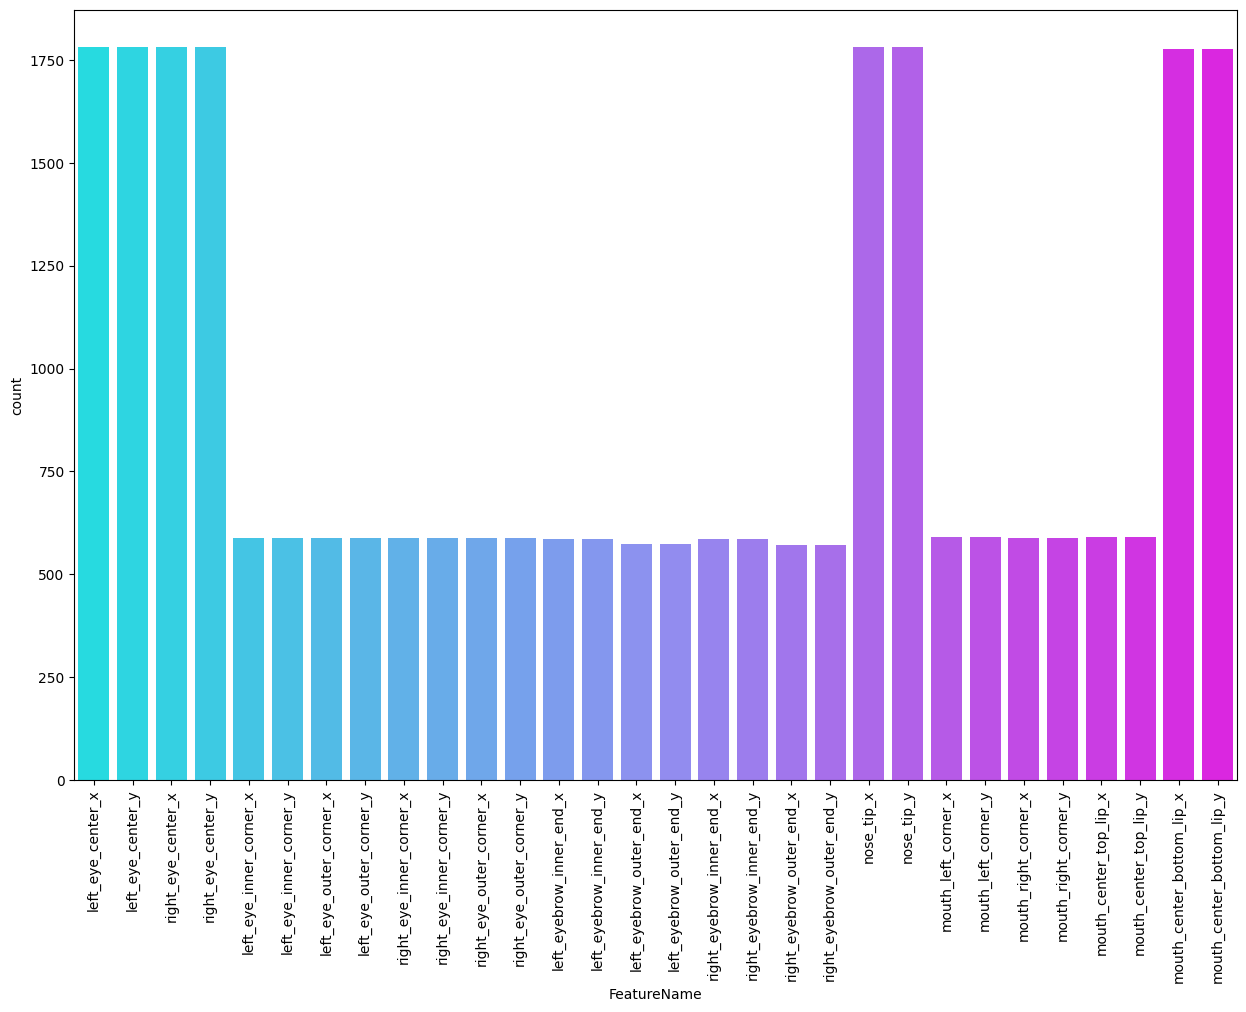

In [44]:
plt.figure(figsize=(15,10))
sns.countplot(x="FeatureName",data=idlookup,palette="cool")
plt.xticks(rotation=90)
plt.show()

In [11]:
idlookup.drop(columns=["Location"],axis=1,inplace=True)

In [12]:
idlookup.shape

(27124, 3)

In [13]:
idlookup.isnull().sum()

RowId          0
ImageId        0
FeatureName    0
dtype: int64

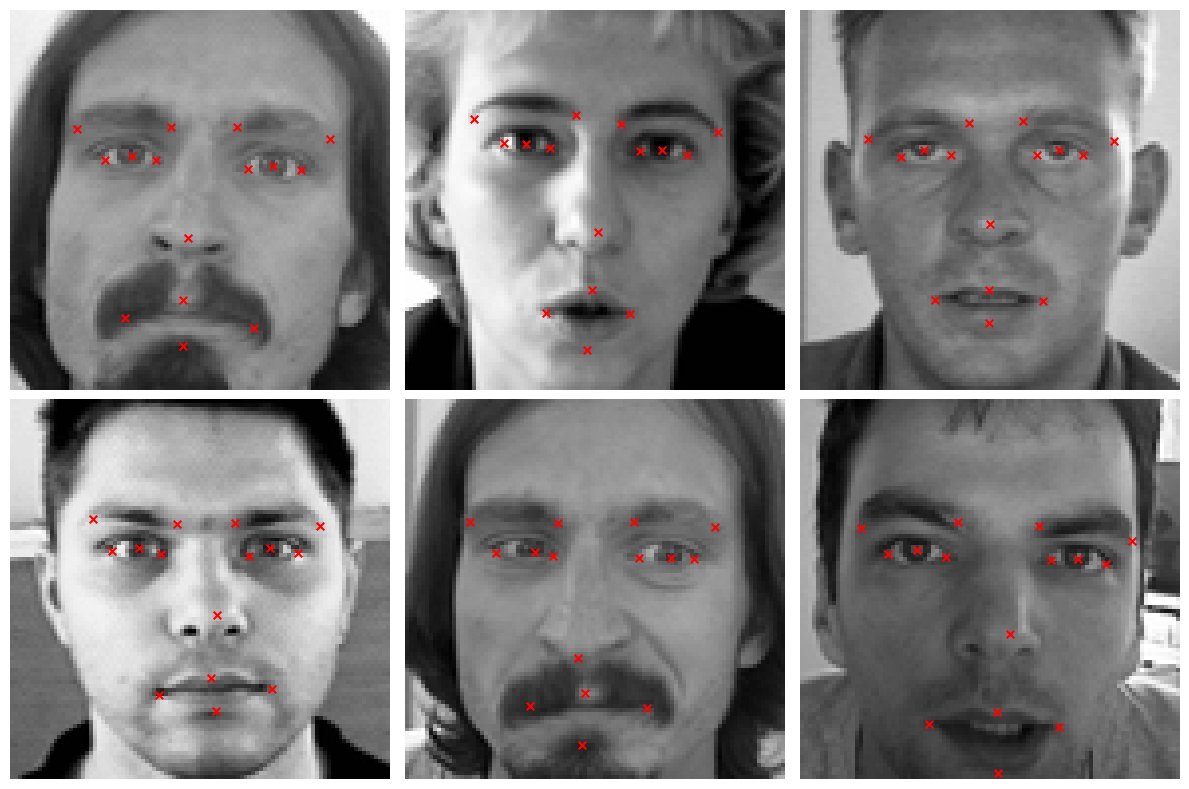

In [14]:
import numpy as np
import matplotlib.pyplot as plt

df["Image"] = df["Image"].apply(lambda x: np.array(x.split(), dtype=np.uint8).reshape(96, 96) if isinstance(x, str) else x)

keypoint_columns_x = [col for col in df.columns if 'x' in col]
keypoint_columns_y = [col.replace('x', 'y') for col in keypoint_columns_x]

def visualize_samples(df, num_samples=6):
    fig, axes = plt.subplots(2, 3, figsize=(12, 8))

    for i, ax in enumerate(axes.flat):
        if i >= num_samples:
            break
        sample_image = df.iloc[i]["Image"]
        sample_keypoints_x = df.iloc[i][keypoint_columns_x].values
        sample_keypoints_y = df.iloc[i][keypoint_columns_y].values

        keypoints = np.column_stack((sample_keypoints_x, sample_keypoints_y))
        
        ax.imshow(sample_image, cmap="gray")
        for (x, y) in keypoints:
            if not np.isnan(x) and not np.isnan(y):
                ax.scatter(x, y, c="red", marker="x", s=30)
        
        ax.axis("off")

    plt.tight_layout()
    plt.show()

visualize_samples(df)


In [15]:
df_merge= pd.merge(df, idlookup, on='ImageId', how='left')

df_merge.head()


,left_eye_center_x,left_eye_center_y,right_eye_center_x,right_eye_center_y,left_eye_inner_corner_x,left_eye_inner_corner_y,left_eye_outer_corner_x,left_eye_outer_corner_y,right_eye_inner_corner_x,right_eye_inner_corner_y,...,mouth_right_corner_x,mouth_right_corner_y,mouth_center_top_lip_x,mouth_center_top_lip_y,mouth_center_bottom_lip_x,mouth_center_bottom_lip_y,Image,ImageId,RowId,FeatureName
0,66.033564,39.002274,30.227008,36.421678,59.582075,39.647423,73.130346,39.969997,36.356571,37.389402,...,28.614496,77.388992,43.312602,72.935459,43.130707,84.485774,"[[238, 236, 237, 238, 240, 240, 239, 241, 241,...",1,1.0,left_eye_center_x
1,66.033564,39.002274,30.227008,36.421678,59.582075,39.647423,73.130346,39.969997,36.356571,37.389402,...,28.614496,77.388992,43.312602,72.935459,43.130707,84.485774,"[[238, 236, 237, 238, 240, 240, 239, 241, 241,...",1,2.0,left_eye_center_y
2,66.033564,39.002274,30.227008,36.421678,59.582075,39.647423,73.130346,39.969997,36.356571,37.389402,...,28.614496,77.388992,43.312602,72.935459,43.130707,84.485774,"[[238, 236, 237, 238, 240, 240, 239, 241, 241,...",1,3.0,right_eye_center_x
3,66.033564,39.002274,30.227008,36.421678,59.582075,39.647423,73.130346,39.969997,36.356571,37.389402,...,28.614496,77.388992,43.312602,72.935459,43.130707,84.485774,"[[238, 236, 237, 238, 240, 240, 239, 241, 241,...",1,4.0,right_eye_center_y
4,66.033564,39.002274,30.227008,36.421678,59.582075,39.647423,73.130346,39.969997,36.356571,37.389402,...,28.614496,77.388992,43.312602,72.935459,43.130707,84.485774,"[[238, 236, 237, 238, 240, 240, 239, 241, 241,...",1,5.0,left_eye_inner_corner_x


In [16]:
df_merge.columns

Index(['left_eye_center_x', 'left_eye_center_y', 'right_eye_center_x',
       'right_eye_center_y', 'left_eye_inner_corner_x',
       'left_eye_inner_corner_y', 'left_eye_outer_corner_x',
       'left_eye_outer_corner_y', 'right_eye_inner_corner_x',
       'right_eye_inner_corner_y', 'right_eye_outer_corner_x',
       'right_eye_outer_corner_y', 'left_eyebrow_inner_end_x',
       'left_eyebrow_inner_end_y', 'left_eyebrow_outer_end_x',
       'left_eyebrow_outer_end_y', 'right_eyebrow_inner_end_x',
       'right_eyebrow_inner_end_y', 'right_eyebrow_outer_end_x',
       'right_eyebrow_outer_end_y', 'nose_tip_x', 'nose_tip_y',
       'mouth_left_corner_x', 'mouth_left_corner_y', 'mouth_right_corner_x',
       'mouth_right_corner_y', 'mouth_center_top_lip_x',
       'mouth_center_top_lip_y', 'mouth_center_bottom_lip_x',
       'mouth_center_bottom_lip_y', 'Image', 'ImageId', 'RowId',
       'FeatureName'],
      dtype='object')

In [17]:
len(df_merge.columns[: -4])

30

In [18]:
df_merge['RowId'] = range(len(df_merge))
# Fill FeatureName with facial keypoint locations based on column names
feature_names = [col.rsplit('_', 1)[0] for col in df_merge.columns if col.endswith('_x')]
df_merge['FeatureName'] = df_merge.apply(lambda row: feature_names[row.name % len(feature_names)], axis=1)

In [19]:
df_merge.isnull().sum()

left_eye_center_x            0
left_eye_center_y            0
right_eye_center_x           0
right_eye_center_y           0
left_eye_inner_corner_x      0
left_eye_inner_corner_y      0
left_eye_outer_corner_x      0
left_eye_outer_corner_y      0
right_eye_inner_corner_x     0
right_eye_inner_corner_y     0
right_eye_outer_corner_x     0
right_eye_outer_corner_y     0
left_eyebrow_inner_end_x     0
left_eyebrow_inner_end_y     0
left_eyebrow_outer_end_x     0
left_eyebrow_outer_end_y     0
right_eyebrow_inner_end_x    0
right_eyebrow_inner_end_y    0
right_eyebrow_outer_end_x    0
right_eyebrow_outer_end_y    0
nose_tip_x                   0
nose_tip_y                   0
mouth_left_corner_x          0
mouth_left_corner_y          0
mouth_right_corner_x         0
mouth_right_corner_y         0
mouth_center_top_lip_x       0
mouth_center_top_lip_y       0
mouth_center_bottom_lip_x    0
mouth_center_bottom_lip_y    0
Image                        0
ImageId                      0
RowId   

In [20]:
df_merge["FeatureName"].value_counts()

FeatureName
left_eye_center            2160
right_eye_center           2160
left_eye_inner_corner      2160
left_eye_outer_corner      2160
right_eye_inner_corner     2160
right_eye_outer_corner     2159
left_eyebrow_inner_end     2159
left_eyebrow_outer_end     2159
right_eyebrow_inner_end    2159
right_eyebrow_outer_end    2159
nose_tip                   2159
mouth_left_corner          2159
mouth_right_corner         2159
mouth_center_top_lip       2159
mouth_center_bottom_lip    2159
Name: count, dtype: int64

# Define hyperparameters

In [21]:
IMG_SIZE = 96
BATCH_SIZE = 32
NUM_KEYPOINTS=30
EPOCH=15

# Visualize data
### Now, we write a utility function to visualize the images and their keypoints.

In [22]:
def visualize_keypoints(images, keypoints, titles=None):
    # Set up the figure
    fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(15, 25))
    [ax.axis('off') for ax in axes.flatten()]
    
    # Define feature groups and their properties
    feature_groups = {
        'eyes': {
            'color': 'red',
            'indices': list(range(0, 12)),  # first 12 coordinates (6 points) are eye-related
            'label': 'Eyes'
        },
        'eyebrows': {
            'color': 'blue',
            'indices': list(range(12, 20)),  # next 8 coordinates (4 points) are eyebrow-related
            'label': 'Eyebrows'
        },
        'nose': {
            'color': 'green',
            'indices': list(range(20, 22)),  # next 2 coordinates (1 point) is nose
            'label': 'Nose'
        },
        'mouth': {
            'color': 'yellow',
            'indices': list(range(22, 30)),  # last 8 coordinates (4 points) are mouth-related
            'label': 'Mouth'
        }
    }
    
    # Process each image
    for idx, (image, keypoint) in enumerate(zip(images, keypoints)):
        if idx >= len(axes):
            break
            
        # Show original image
        axes[idx, 0].imshow(image, cmap='gray')
        axes[idx, 0].set_title(f'Original Image {idx+1}')
        
        # Show image with keypoints
        axes[idx, 1].imshow(image, cmap='gray')
        axes[idx, 1].set_title(f'Facial Keypoints {idx+1}')
        
        # Reshape keypoints to (x,y) pairs
        keypoint_coords = keypoint.reshape(-1, 2)
        
        # Plot each feature group
        for group_name, group_info in feature_groups.items():
            start_idx = group_info['indices'][0] // 2
            end_idx = (group_info['indices'][-1] // 2) + 1
            
            # Get keypoints for this feature group
            group_keypoints = keypoint_coords[start_idx:end_idx]
            
            # Plot points
            for x, y in group_keypoints:
                # Convert normalized coordinates to pixel coordinates
                x_px = x * IMG_SIZE
                y_px = y * IMG_SIZE
                
                # Plot point
                axes[idx, 1].scatter(
                    x_px, y_px,
                    c=group_info['color'],
                    marker='x',
                    s=100,
                    linewidth=2,
                    label=group_info['label']
                )
                
                # Add circle for visibility
                circle = plt.Circle(
                    (x_px, y_px),
                    2,
                    color=group_info['color'],
                    fill=False,
                    linewidth=1
                )
                axes[idx, 1].add_artist(circle)
        
        # Add legend to first image only
        if idx == 0:
            # Create legend handles
            handles = [plt.Line2D(
                [0], [0],
                marker='x',
                color='w',
                markerfacecolor=group_info['color'],
                markersize=10,
                label=group_info['label'],
                markeredgecolor=group_info['color']
            ) for group_info in feature_groups.values()]
            
            # Add legend
            axes[idx, 1].legend(
                handles=handles,
                bbox_to_anchor=(1.05, 1),
                loc='upper left',
                borderaxespad=0.
            )
    
    plt.tight_layout()
    plt.show()


# Prepare data generator

In [23]:

class KeyPointsDataset:
    def __init__(self, data, aug_pipeline, batch_size=32):
        self.data = data.copy()
        self.aug_pipeline = aug_pipeline
        self.batch_size = batch_size
        
        # Define feature columns in exact order
        self.feature_columns = [
            'left_eye_center_x', 'left_eye_center_y',
            'right_eye_center_x', 'right_eye_center_y',
            'left_eye_inner_corner_x', 'left_eye_inner_corner_y',
            'left_eye_outer_corner_x', 'left_eye_outer_corner_y',
            'right_eye_inner_corner_x', 'right_eye_inner_corner_y',
            'right_eye_outer_corner_x', 'right_eye_outer_corner_y',
            'left_eyebrow_inner_end_x', 'left_eyebrow_inner_end_y',
            'left_eyebrow_outer_end_x', 'left_eyebrow_outer_end_y',
            'right_eyebrow_inner_end_x', 'right_eyebrow_inner_end_y',
            'right_eyebrow_outer_end_x', 'right_eyebrow_outer_end_y',
            'nose_tip_x', 'nose_tip_y',
            'mouth_left_corner_x', 'mouth_left_corner_y',
            'mouth_right_corner_x', 'mouth_right_corner_y',
            'mouth_center_top_lip_x', 'mouth_center_top_lip_y',
            'mouth_center_bottom_lip_x', 'mouth_center_bottom_lip_y'
        ]
        
        self.image_ids = self.data['ImageId'].values
        self.indexes = np.arange(len(self.image_ids))
        np.random.shuffle(self.indexes)

    def __len__(self):
        
        total_batches= int(np.floor(len(self.image_ids) / self.batch_size))
        print(f"Total batches : {total_batches}")
        return total_batches
        

    def get_image(self, image_id):
        image_data = self.data[self.data["ImageId"] == image_id]["Image"].iloc[0]
        
        # Convert string of pixels to numpy array
        if isinstance(image_data, str):
            image = np.array([int(pixel) for pixel in image_data.split()], dtype=np.uint8)
        else:
            image = np.array(image_data, dtype=np.uint8)
            
        # Reshape to correct dimensions
        image = image.reshape(IMG_SIZE, IMG_SIZE)
        
        # Convert to RGB (3 channels)
        image = np.repeat(image[:, :, np.newaxis], 3, axis=-1)
        return image

    def get_keypoints(self, image_id):
        row = self.data[self.data['ImageId'] == image_id].iloc[0]
        keypoints = []
        
        # Get keypoints in exact order of feature_columns
        for col in self.feature_columns:
            value = row[col]
            # Normalize the coordinate value
            if not np.isnan(value):
                value = value / IMG_SIZE  # Normalize to [0,1]
            else:
                value = 0.5  # Center point for missing values
            keypoints.append(value)
            
        return np.array(keypoints, dtype=np.float32)

    def __getitem__(self, index):
        # Get batch indexes
        start_idx = index * self.batch_size
        end_idx = (index + 1) * self.batch_size
        indexes = self.indexes[start_idx:end_idx]
        
        # Get batch image IDs
        batch_image_ids = [self.image_ids[k] for k in indexes]
        
        batch_images = []
        batch_keypoints = []
        
        for image_id in batch_image_ids:
            image = self.get_image(image_id)
            keypoints = self.get_keypoints(image_id)
            
            if len(keypoints) > 0:
                batch_images.append(image)
                batch_keypoints.append(keypoints)
        
        if len(batch_images) == 0:
            return np.empty((0, IMG_SIZE, IMG_SIZE, 3)), np.empty((0, len(self.feature_columns)))
            
        return self.__data_generation(batch_images, batch_keypoints)

    def __data_generation(self, batch_images, batch_keypoints):
        batch_size = len(batch_images)
        batch_images_array = np.empty((batch_size, IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
        batch_keypoints_array = np.empty((batch_size, len(self.feature_columns)), dtype=np.float32)

        for i, (image, keypoint) in enumerate(zip(batch_images, batch_keypoints)):
            # Create keypoints for augmentation
            keypoint_pairs = keypoint.reshape(-1, 2)  # Reshape to (x,y) pairs
            keypoints_list = [
                Keypoint(x=x * IMG_SIZE, y=y * IMG_SIZE)
                for x, y in keypoint_pairs
            ]
            kps = KeypointsOnImage(keypoints_list, shape=image.shape)

            # Apply augmentation
            augmented_image, augmented_kps = self.aug_pipeline(image=image, keypoints=kps)

            # Fallback if augmentation produces invalid image
            if np.mean(augmented_image) < 10:
                augmented_image = image
                augmented_kps = kps

            batch_images_array[i] = augmented_image

            # Process augmented keypoints
            flattened_keypoints = []
            for kp in augmented_kps.keypoints:
                x_norm = np.clip(kp.x / IMG_SIZE, 0, 1)
                y_norm = np.clip(kp.y / IMG_SIZE, 0, 1)
                flattened_keypoints.extend([x_norm, y_norm])

            # Fallback if augmentation fails
            if len(flattened_keypoints) == 0:
                flattened_keypoints = keypoint

            batch_keypoints_array[i] = np.array(flattened_keypoints)

        return batch_images_array, batch_keypoints_array



# Define augmentation transforms

In [24]:
train_aug = iaa.Sequential(
    [
        iaa.Resize(IMG_SIZE, interpolation="linear"),
        iaa.Fliplr(0.3),
        # `Sometimes()` applies a function randomly to the inputs with
        # a given probability (0.3, in this case).
        iaa.Sometimes(0.3, iaa.Affine(rotate=10, scale=(0.5, 0.7))),
    ]
)

test_aug = iaa.Sequential([iaa.Resize(IMG_SIZE, interpolation="linear")])

# Data generator investigation

Sample batch shapes:
Images: (32, 96, 96, 3)
Keypoints: (32, 30)

Keypoint value ranges:
Min: 0.114
Max: 0.930


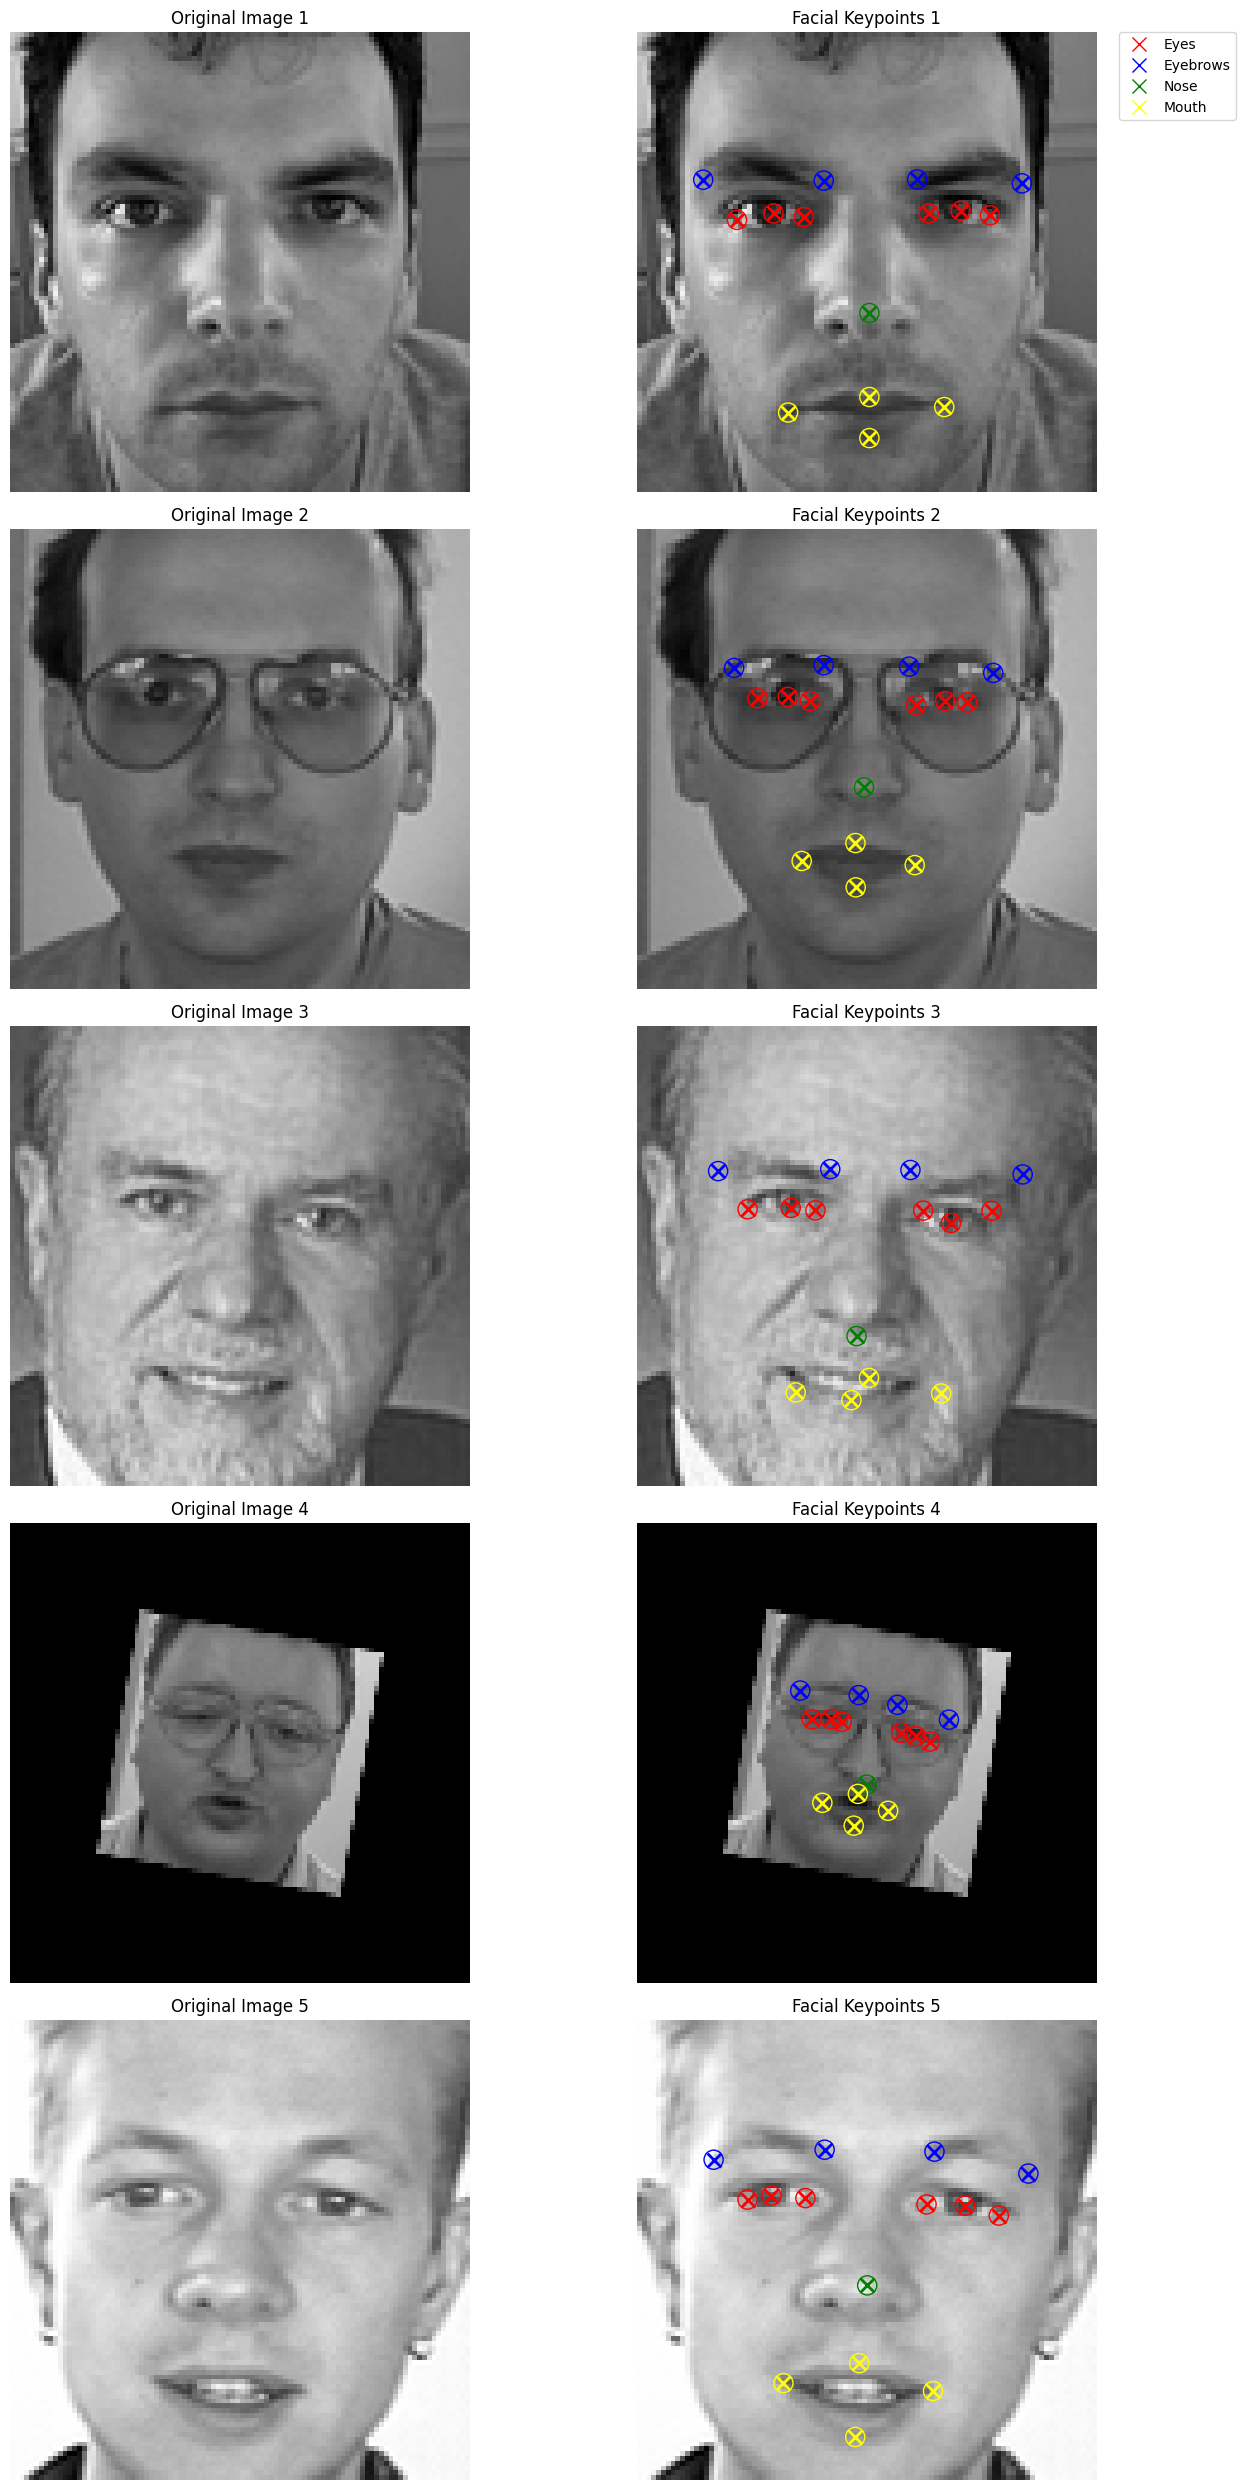

In [25]:

train_dataset = KeyPointsDataset(data=df_merge, aug_pipeline=train_aug, batch_size=BATCH_SIZE)
valid_dataset = KeyPointsDataset(data=df_merge, aug_pipeline=test_aug, batch_size=BATCH_SIZE)

# Test the dataset
sample_images, sample_keypoints = train_dataset.__getitem__(0)
print(f"Sample batch shapes:")
print(f"Images: {sample_images.shape}")
print(f"Keypoints: {sample_keypoints.shape}")

# Verify keypoint ranges
print(f"\nKeypoint value ranges:")
print(f"Min: {sample_keypoints.min():.3f}")
print(f"Max: {sample_keypoints.max():.3f}")
visualize_keypoints(sample_images, sample_keypoints)

# Convert dataset into a TensorFlow format

In [26]:
def generator(dataset):
    for img, label in dataset:
        for i in range(len(img)):
            yield img[i], label[i]

# Create the TensorFlow dataset for training
train_tf_dataset = tf.data.Dataset.from_generator(
    lambda: generator(train_dataset),
    output_signature=(
        tf.TensorSpec(shape=(IMG_SIZE, IMG_SIZE, 3), dtype=tf.uint8),  # Individual image
        tf.TensorSpec(shape=(len(train_dataset.feature_columns),), dtype=tf.float32),  # Individual keypoints
    )
).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)  

# Create the TensorFlow dataset for validation
valid_tf_dataset = tf.data.Dataset.from_generator(
    lambda: generator(valid_dataset),
    output_signature=(
        tf.TensorSpec(shape=(IMG_SIZE, IMG_SIZE, 3), dtype=tf.uint8),  # Individual image
        tf.TensorSpec(shape=(len(valid_dataset.feature_columns),), dtype=tf.float32),  # Individual keypoints
    )
).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


# Model building


In [27]:
def get_model():
    backbone = keras.applications.MobileNetV2(weights="imagenet", include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
    backbone.trainable = False

    inputs = layers.Input((IMG_SIZE, IMG_SIZE, 3))
    x = keras.applications.mobilenet_v2.preprocess_input(inputs)
    x = backbone(x)
    
    # Reduce feature map dimensions
    x = layers.GlobalAveragePooling2D()(x)
    
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dense(64, activation="relu")(x)
    outputs = layers.Dense(NUM_KEYPOINTS, activation="sigmoid")(x)  # Output keypoints

    return keras.Model(inputs, outputs, name="keypoint_detector")

model = get_model()

def rmse(y_true, y_pred):
    return tf.sqrt(tf.reduce_mean(tf.square(y_pred - y_true)))
    
model.compile(loss="mse",optimizer=keras.optimizers.Adam(1e-4),metrics=[rmse])
model.summary()

Model: "keypoint_detector"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 96, 96, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ true_divide (TrueDivide)             │ (None, 96, 96, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ subtract (Subtract)                  │ (None, 96, 96, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_96 (Functional)     │ (None, 3, 3, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         163,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 30)                  │           1,950 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,432,158 (9.28 MB)

 Trainable params: 174,174 (680.37 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

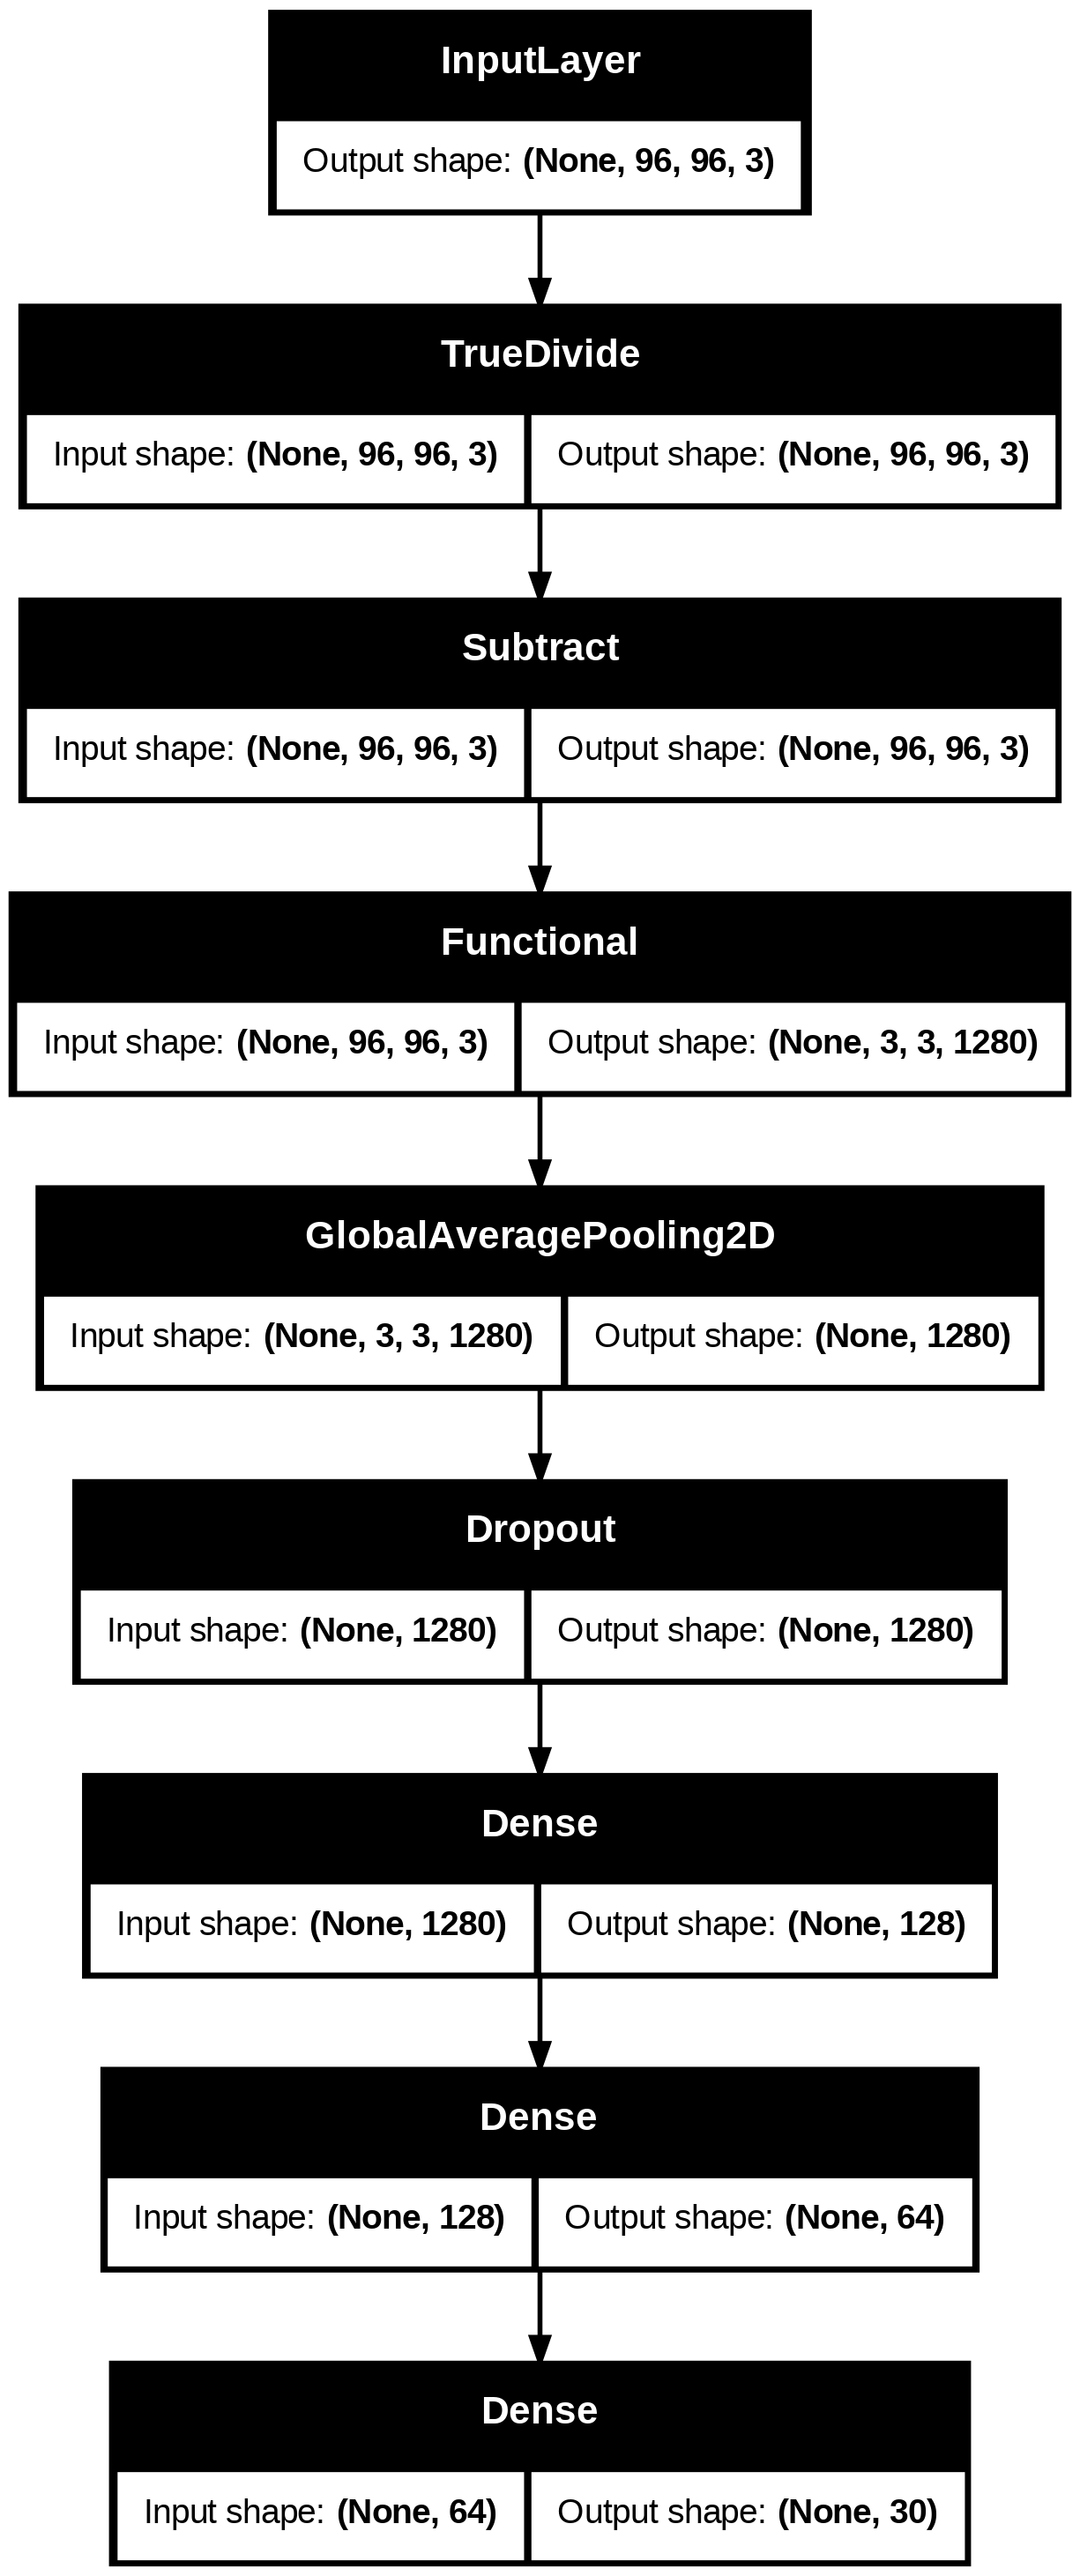

In [28]:
keras.utils.plot_model(model, show_shapes=True)

In [29]:
steps_per_epoch = len(train_dataset) // BATCH_SIZE
validation_steps = len(valid_dataset) // BATCH_SIZE


Total batches : 1012
Total batches : 1012


In [30]:
history = model.fit(train_tf_dataset,validation_data=valid_tf_dataset,epochs=EPOCH,steps_per_epoch=steps_per_epoch,
                    validation_steps=validation_steps)


Epoch 1/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 15s 223ms/step - loss: 0.0615 - rmse: 0.2463 - val_loss: 0.0279 - val_rmse: 0.1669
Epoch 2/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 149ms/step - loss: 0.0306 - rmse: 0.1748 - val_loss: 0.0197 - val_rmse: 0.1402
Epoch 3/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 159ms/step - loss: 0.0232 - rmse: 0.1523 - val_loss: 0.0144 - val_rmse: 0.1200
Epoch 4/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 183ms/step - loss: 0.0214 - rmse: 0.1459 - val_loss: 0.0119 - val_rmse: 0.1091
Epoch 5/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 165ms/step - loss: 0.0179 - rmse: 0.1334 - val_loss: 0.0104 - val_rmse: 0.1019
Epoch 6/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 155ms/step - loss: 0.0168 - rmse: 0.1292 - val_loss: 0.0094 - val_rmse: 0.0971
Epoch 7/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 161ms/step - loss: 0.0169 - rmse: 0.1297 - val_loss: 0.0096 - val_rmse: 0.0981
Epoch 8/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 178ms/step - loss: 0.0170 - rmse: 0.1301 - val_loss: 0.0100 - val_rmse: 0.0998
Epoch 9/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 5

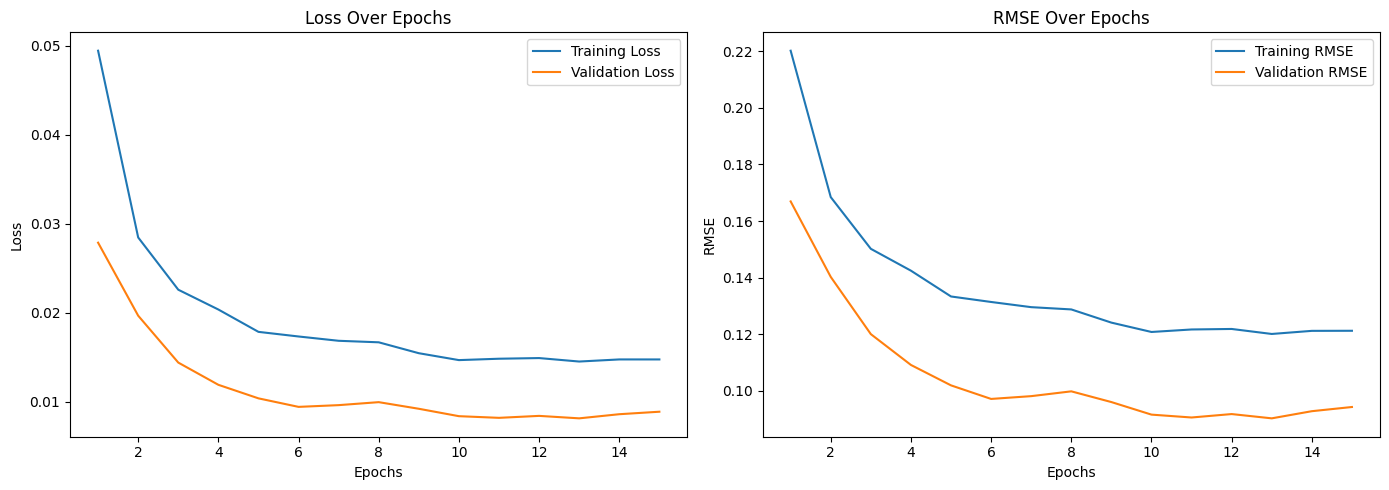

In [39]:
loss = history.history['loss']
val_loss = history.history['val_loss']
rmse = history.history['rmse']
val_rmse = history.history['val_rmse']

# Plot loss and RMSE
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot loss
axes[0].plot(range(1, len(loss) + 1), loss, label='Training Loss')
axes[0].plot(range(1, len(val_loss) + 1), val_loss, label='Validation Loss')
axes[0].set_title('Loss Over Epochs')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()

# Plot RMSE
axes[1].plot(range(1, len(rmse) + 1), rmse, label='Training RMSE')
axes[1].plot(range(1, len(val_rmse) + 1), val_rmse, label='Validation RMSE')
axes[1].set_title('RMSE Over Epochs')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('RMSE')
axes[1].legend()

plt.tight_layout()
plt.show()

# Make predictions and visualize them

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


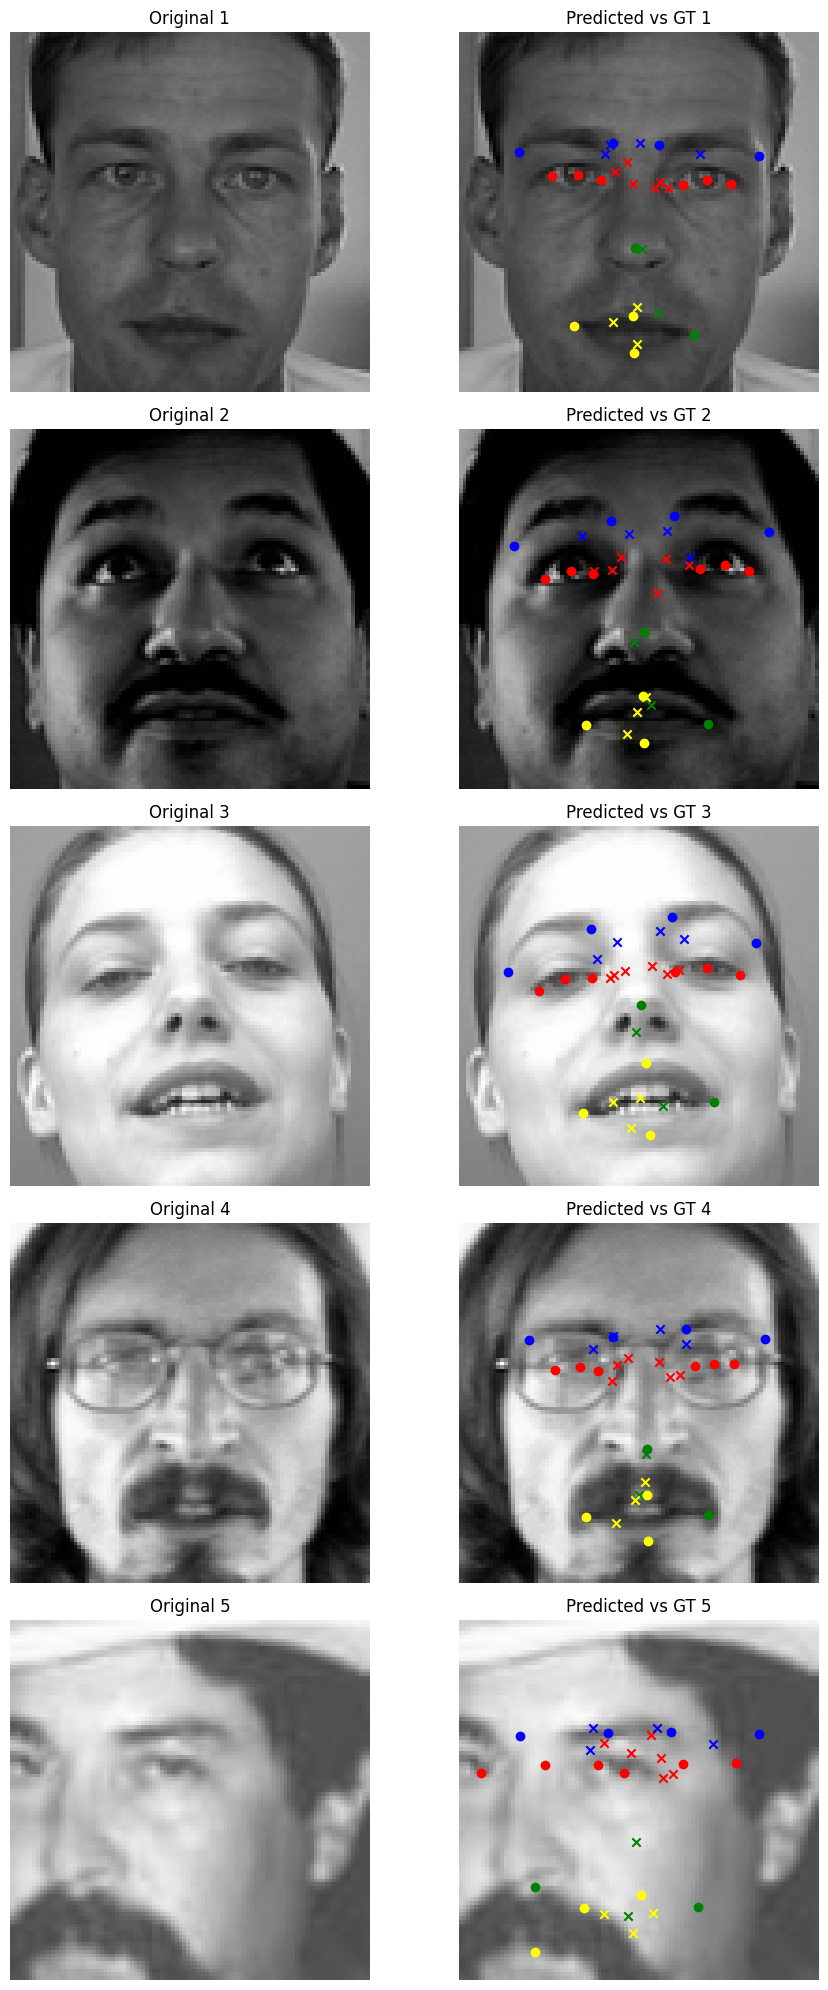

In [31]:


sample_val_images, sample_val_keypoints = next(iter(valid_tf_dataset))

sample_val_images_np = sample_val_images.numpy()
sample_val_keypoints_np = sample_val_keypoints.numpy()

predictions = model.predict(sample_val_images_np)

IMG_SIZE = 96
num_features_per_point = 2
num_points = sample_val_keypoints_np.shape[1] // num_features_per_point

predictions_reshaped = predictions.reshape(-1, num_points, num_features_per_point) * IMG_SIZE
sample_val_keypoints_reshaped = sample_val_keypoints_np.reshape(-1, num_points, num_features_per_point) * IMG_SIZE

feature_groups = {
    'eyes': {'color': 'red', 'indices': list(range(0, 6)), 'label': 'Eyes'},  # First 6 keypoints
    'eyebrows': {'color': 'blue', 'indices': list(range(6, 10)), 'label': 'Eyebrows'},  # Next 4 keypoints
    'nose': {'color': 'green', 'indices': list(range(10, 12)), 'label': 'Nose'},  # 2 keypoints
    'mouth': {'color': 'yellow', 'indices': list(range(12,15)), 'label': 'Mouth'}  # Last 3 keypoints
}

fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(10, 20))

for i in range(5):
    axes[i, 0].imshow(sample_val_images_np[i], cmap="gray")
    axes[i, 0].set_title(f"Original {i+1}")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(sample_val_images_np[i], cmap="gray")
    
    for group in feature_groups.values():
        indices = np.array(group['indices'])
        axes[i, 1].scatter(predictions_reshaped[i, indices, 0], predictions_reshaped[i, indices, 1], c=group['color'], marker='x')
        axes[i, 1].scatter(sample_val_keypoints_reshaped[i, indices, 0], sample_val_keypoints_reshaped[i, indices, 1], c=group['color'], marker='o')

    axes[i, 1].set_title(f"Predicted vs GT {i+1}")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()


In [32]:
test_data=pd.read_csv("/kaggle/input/facial-keypoints-detection/test.zip",compression="zip")

In [33]:
test_data.head()

,ImageId,Image
0,1,182 183 182 182 180 180 176 169 156 137 124 10...
1,2,76 87 81 72 65 59 64 76 69 42 31 38 49 58 58 4...
2,3,177 176 174 170 169 169 168 166 166 166 161 14...
3,4,176 174 174 175 174 174 176 176 175 171 165 15...
4,5,50 47 44 101 144 149 120 58 48 42 35 35 37 39 ...


In [34]:
RowId=test_data.ImageId

In [35]:
test_data.head()

,ImageId,Image
0,1,182 183 182 182 180 180 176 169 156 137 124 10...
1,2,76 87 81 72 65 59 64 76 69 42 31 38 49 58 58 4...
2,3,177 176 174 170 169 169 168 166 166 166 161 14...
3,4,176 174 174 175 174 174 176 176 175 171 165 15...
4,5,50 47 44 101 144 149 120 58 48 42 35 35 37 39 ...


In [36]:
test_data.drop(columns=["ImageId"],axis=1,inplace=True)

In [37]:


def preprocess_image(row):
    pixels = np.array(row.split(), dtype=np.float32)
    pixels = pixels.reshape(96, 96, 1)
    pixels = np.repeat(pixels, 3, axis=-1)
    pixels = pixels / 255.0
    return pixels

processed_images = np.array([preprocess_image(row) for row in test_data["Image"]])

print("Processed Image Shape:", processed_images.shape)

predictions = model.predict(processed_images)

lookid_list = list(idlookup['FeatureName'])
imageId = list(idlookup['ImageId'] - 1)
rowid = list(idlookup['RowId'])

feature = [lookid_list.index(f) for f in lookid_list]

location = [predictions[x][y] for x, y in zip(imageId, feature)]

submission = pd.DataFrame({'RowId': rowid, 'Location': location})

submission.to_csv('facial_keypoints_detection_submission.csv', index=False)

print("Submission file saved successfully!")


Processed Image Shape: (1783, 96, 96, 3)
56/56 ━━━━━━━━━━━━━━━━━━━━ 6s 61ms/step
Submission file saved successfully!


In [38]:
submission.head()

,RowId,Location
0,1,0.433462
1,2,0.409924
2,3,0.520385
3,4,0.439395
4,5,0.487752
